In [12]:
pip install pandas scikit-learn jupyter

In [24]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [25]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\u0B80-\u0BFF\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [26]:
X = []
y = []

base_path = "train"

for dialect in os.listdir(base_path):
    dialect_path = os.path.join(base_path, dialect)
    
    if os.path.isdir(dialect_path):
        for file in os.listdir(dialect_path):
            file_path = os.path.join(dialect_path, file)
            
            with open(file_path, encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line:
                        X.append(clean_text(line))
                        y.append(dialect)

print("Total samples:", len(X))

Total samples: 5134


In [27]:
from collections import Counter
print(Counter(y))

Counter({'Northern_Dialect': 1696, 'Southern_Dialect': 1427, 'Western_Dialect': 1126, 'Central_Dialect': 885})


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4107
Test size: 1027


In [29]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        n_jobs=-1
    ))
])

In [30]:
param_grid = {
    "tfidf__ngram_range": [(3,5), (4,6), (5,7)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.9, 0.95],
    "clf__C": [0.5, 1, 2, 4, 6]
}

In [31]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(analyzer='char',
                                                        sublinear_tf=True)),
                                       ('clf',
                                        LogisticRegression(max_iter=5000,
                                                           n_jobs=-1))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.5, 1, 2, 4, 6],
                         'tfidf__max_df': [0.9, 0.95],
                         'tfidf__min_df': [1, 2, 3],
                         'tfidf__ngram_range': [(3, 5), (4, 6), (5, 7)]},
             scoring='accuracy', verbose=2)

In [20]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9090909090909091
                  precision    recall  f1-score   support

 Central_Dialect       1.00      1.00      1.00         6
Northern_Dialect       1.00      1.00      1.00         4
Southern_Dialect       0.78      1.00      0.88         7
 Western_Dialect       1.00      0.60      0.75         5

        accuracy                           0.91        22
       macro avg       0.94      0.90      0.91        22
    weighted avg       0.93      0.91      0.90        22



In [32]:
print("Best CV Accuracy:", grid.best_score_)
print("Best Parameters:")
for k, v in grid.best_params_.items():
    print(f"{k}: {v}")


Best CV Accuracy: 0.9194030779626058
Best Parameters:
clf__C: 6
tfidf__max_df: 0.9
tfidf__min_df: 2
tfidf__ngram_range: (3, 5)


In [33]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9230769230769231

Classification Report:

                  precision    recall  f1-score   support

 Central_Dialect       1.00      0.96      0.98       177
Northern_Dialect       0.89      0.92      0.90       339
Southern_Dialect       0.87      0.87      0.87       286
 Western_Dialect       0.98      0.97      0.98       225

        accuracy                           0.92      1027
       macro avg       0.94      0.93      0.93      1027
    weighted avg       0.92      0.92      0.92      1027



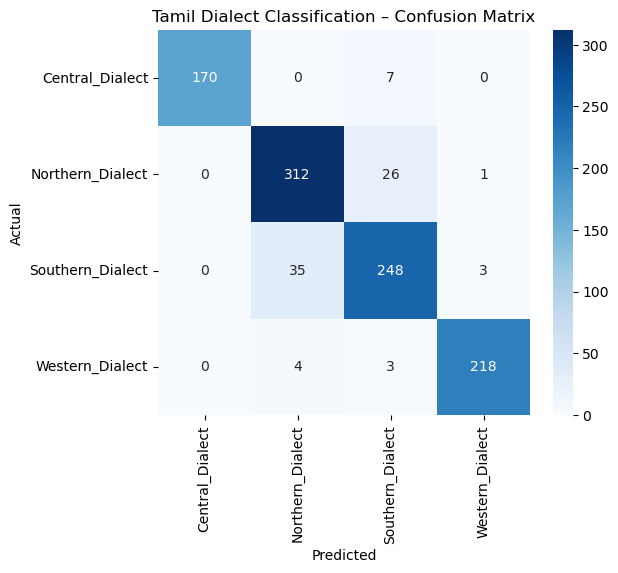

In [34]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tamil Dialect Classification – Confusion Matrix")
plt.show()

In [35]:
import joblib

joblib.dump(best_model, "tamil_dialect_text_model.pkl")
print("Model saved successfully")

Model saved successfully


In [36]:
import joblib

model = joblib.load("tamil_dialect_text_model.pkl")

In [37]:
def predict_dialect(text):
    text = clean_text(text)
    prediction = model.predict([text])[0]
    confidence = model.predict_proba([text])[0]
    
    classes = model.classes_
    probs = dict(zip(classes, confidence))
    
    return prediction, probs

In [41]:
test_text = "எனுங்க எந்தர சர இப்ப கெளம்பிட்டீங்கள பொத்த வாழத்துக்கு"

dialect, confidence = predict_dialect(test_text)

print("Input Text:")
print(test_text)
print("\nPredicted Dialect:", dialect)
print("\nConfidence Scores:")
for k, v in confidence.items():
    print(f"{k}: {v:.3f}")

Input Text:
எனுங்க எந்தர சர இப்ப கெளம்பிட்டீங்கள பொத்த வாழத்துக்கு

Predicted Dialect: Western_Dialect

Confidence Scores:
Central_Dialect: 0.169
Northern_Dialect: 0.115
Southern_Dialect: 0.320
Western_Dialect: 0.397
